# Profiling

In [1]:
import time
from lucifex.fdm import AB, CN
from lucifex.sim import run, xdmf_to_npz, GridSimulationFromNPZ
from lucifex.solver import OptionsPETSc
from lucifex.viz import (
    plot_line, save_figure, 
    get_ipynb_file_name, set_ipynb_variable,
)
from crocodil.dns.system_a import dns_system_a, SYSTEM_A_REFERENCE 

STORE = 1
WRITE = 1
DIR_ROOT = f'.figures/{get_ipynb_file_name()}'
NX = 60
NY = 60

simulation = dns_system_a(
    store_delta=STORE, 
    write_delta=WRITE, 
    dir_root=DIR_ROOT, 
)(
    Nx=NX,
    Ny=NY,
    scaling='advective',
    **SYSTEM_A_REFERENCE,
    D_adv=AB(1)@CN, 
    D_diff=AB(1)@CN,
    dt_max=0.1,
    courant_adv=0.75,
    courant_diff=0.75,
    courant_reac=0.1,
    flow_petsc=(OptionsPETSc('cg', 'hypre'), None),
    diagnostic=True,
)

n_stop = set_ipynb_variable('N_STOP', 100)
dt_init = 1e-6
n_init = 6
run(simulation, n_stop=n_stop, dt_init=dt_init, n_init=n_init, timing=True)

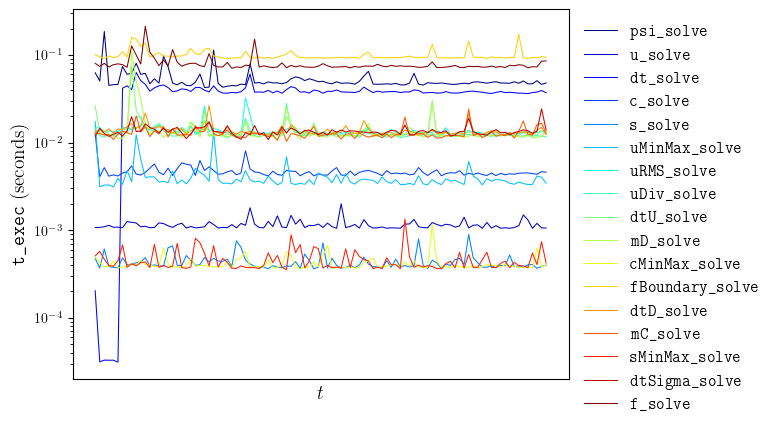

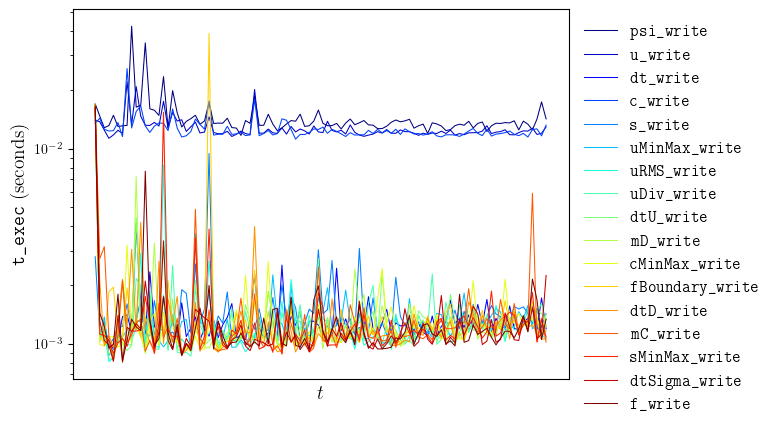

In [2]:
timings = simulation.timings
key_filter = lambda k, sub: sub in k

for sub in ('solve', 'write'):
    lines = [(range(len(v)), v) for k, v in timings.items() if key_filter(k, sub)]
    legend_labels = [f'$\\texttt{{{k}}}$' for k in timings if key_filter(k, sub)]
    fig, ax = plot_line(
        lines,
        cyc='jet',
        legend_labels=legend_labels,
        x_label='$t$',
        y_label='$\\texttt{t\\_exec}$ (seconds)',
    )
    ax.set_xticks([])
    ax.set_yscale('log')
    save_figure(f'tExec(t)_{sub}', simulation.dir_path, prefix=False)(fig)

In [3]:
t_start = time.perf_counter()
xdmf_to_npz(simulation)
t_end = time.perf_counter()
print(t_end - t_start)

8.769501051981933


In [ ]:
function_series = ('c', 'psi')
constant_series = ('mC', 'mD')

sim_npz = GridSimulationFromNPZ(
    simulation.dir_path,
    function_series,
    constant_series,
    lazy=True,
)

for name in (*function_series, *constant_series):
    t_start = time.perf_counter()
    series = sim_npz[name]
    t_end = time.perf_counter()
    print(name, t_end - t_start)


c 0.05457665800349787
psi 0.046102689986582845
mC 0.012938368949107826
mD 0.017584457993507385


: 